In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings

warnings.filterwarnings("ignore")

In [60]:
df=pd.read_csv("data/Car_Price_Prediction.csv")

df.head()

,Make,Model,Year,Engine Size,Mileage,Fuel Type,Transmission,Price
0,Honda,Model B,2015,3.9,74176,Petrol,Manual,30246.207931
1,Ford,Model C,2014,1.7,94799,Electric,Automatic,22785.747684
2,BMW,Model B,2006,4.1,98385,Electric,Manual,25760.290347
3,Honda,Model B,2015,2.6,88919,Electric,Automatic,25638.003491
4,Honda,Model C,2004,3.4,138482,Petrol,Automatic,21021.386657


In [61]:
df.isnull().sum()

Make            0
Model           0
Year            0
Engine Size     0
Mileage         0
Fuel Type       0
Transmission    0
Price           0
dtype: int64

In [62]:
df.duplicated().sum()

np.int64(0)

In [63]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Make          1000 non-null   str    
 1   Model         1000 non-null   str    
 2   Year          1000 non-null   int64  
 3   Engine Size   1000 non-null   float64
 4   Mileage       1000 non-null   int64  
 5   Fuel Type     1000 non-null   str    
 6   Transmission  1000 non-null   str    
 7   Price         1000 non-null   float64
dtypes: float64(2), int64(2), str(4)
memory usage: 87.5 KB


In [64]:
df.columns

Index(['Make', 'Model', 'Year', 'Engine Size', 'Mileage', 'Fuel Type',
       'Transmission', 'Price'],
      dtype='str')

In [65]:
df["Price"].value_counts()

Price
30246.207931    1
22785.747684    1
25760.290347    1
25638.003491    1
21021.386657    1
               ..
22765.597091    1
30392.575567    1
16446.892292    1
27396.156708    1
31620.864907    1
Name: count, Length: 1000, dtype: int64

In [66]:
df["Price"].describe()

count     1000.000000
mean     25136.615530
std       5181.401368
min       6704.953524
25%      21587.878370
50%      25189.325247
75%      28806.368974
max      41780.504635
Name: Price, dtype: float64

Text(0.5, 1.0, 'Price Distribution')

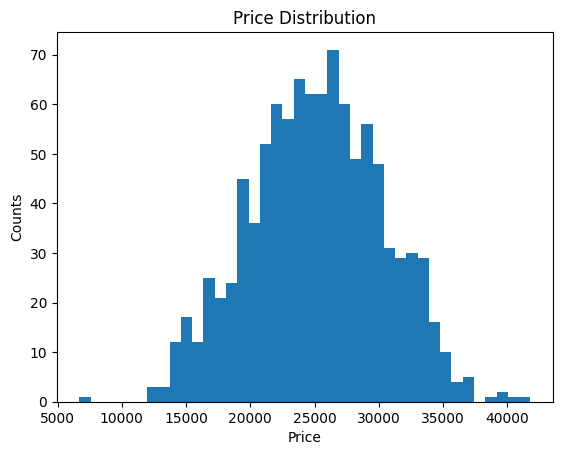

In [67]:
plt.hist(df["Price"],bins=40)
plt.xlabel("Price")
plt.ylabel("Counts")

plt.title("Price Distribution")


In [68]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Make          1000 non-null   str    
 1   Model         1000 non-null   str    
 2   Year          1000 non-null   int64  
 3   Engine Size   1000 non-null   float64
 4   Mileage       1000 non-null   int64  
 5   Fuel Type     1000 non-null   str    
 6   Transmission  1000 non-null   str    
 7   Price         1000 non-null   float64
dtypes: float64(2), int64(2), str(4)
memory usage: 87.5 KB


In [69]:
categorical_columns=[
    "Make","Model","Fuel Type","Transmission"
]

numerical_columns=[
    "Year","Engine Size","Mileage","Price"
]

In [70]:
print(categorical_columns)
print()
print(numerical_columns)

['Make', 'Model', 'Fuel Type', 'Transmission']

['Year', 'Engine Size', 'Mileage', 'Price']


In [71]:
df[["Make", "Model", "Fuel Type", "Transmission"]].nunique()

Make            5
Model           5
Fuel Type       3
Transmission    2
dtype: int64

In [72]:
df[["Make", "Model", "Fuel Type", "Transmission"]].apply(lambda x: x.unique())

Make                         [Honda, Ford, BMW, Audi, Toyota]
Model           [Model B, Model C, Model A, Model D, Model E]
Fuel Type                          [Petrol, Electric, Diesel]
Transmission                              [Manual, Automatic]
dtype: object

In [73]:
df[["Mileage", "Engine Size", "Year"]].apply(lambda x: x.unique())

Mileage        [74176, 94799, 98385, 88919, 138482, 81462, 17...
Engine Size    [3.9, 1.7, 4.1, 2.6, 3.4, 2.7, 1.3, 2.0, 4.4, ...
Year           [2015, 2014, 2006, 2004, 2000, 2018, 2021, 201...
dtype: object

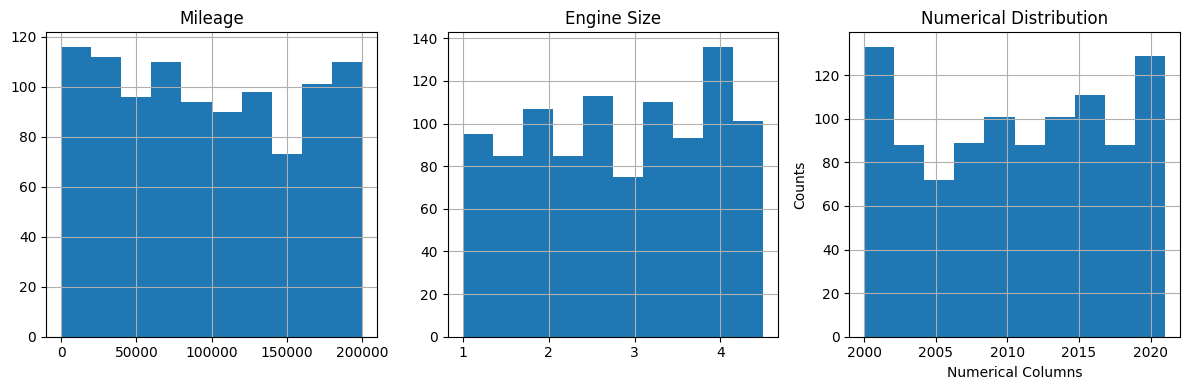

In [74]:
df[["Mileage", "Engine Size", "Year"]].hist(layout=(1,3),figsize=(12,4))

plt.xlabel("Numerical Columns")
plt.ylabel("Counts")
plt.title("Numerical Distribution")

plt.savefig("images/numerical_distriburion.png")

plt.tight_layout()


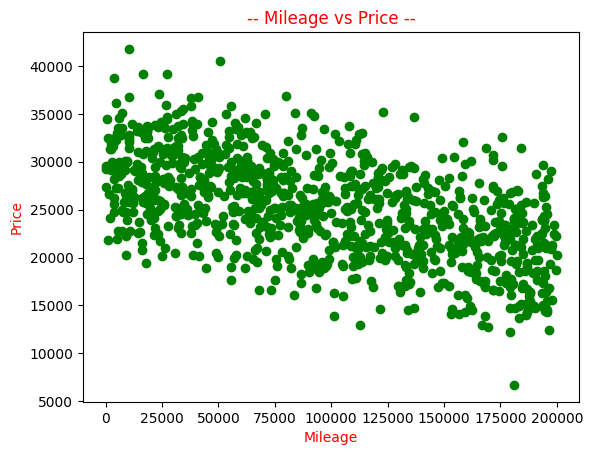

In [75]:
plt.scatter(df["Mileage"],df["Price"],color="green")
plt.xlabel("Mileage",color="red")
plt.ylabel("Price",color="red")

plt.title("-- Mileage vs Price --" ,color="red")
plt.savefig("images/Mileage_vs_Price.png")

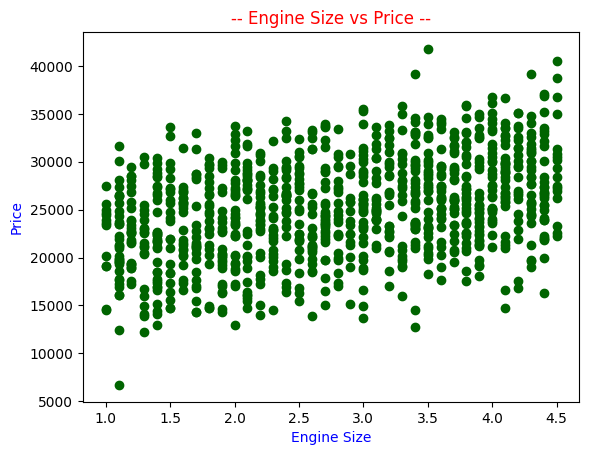

In [76]:
plt.scatter(df["Engine Size"],df["Price"],color="darkgreen")
plt.xlabel("Engine Size",color="blue")
plt.ylabel("Price",color="blue")

plt.title("-- Engine Size vs Price --" ,color="red")
plt.savefig("images/Engine_size_vs_Price.png")

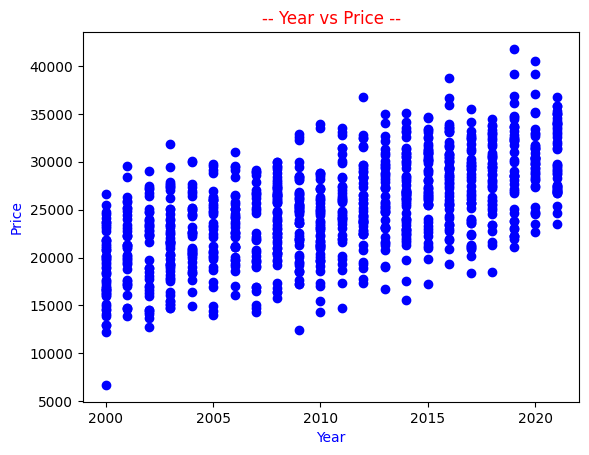

In [77]:
plt.scatter(df["Year"],df["Price"],color="blue")
plt.xlabel("Year",color="blue")
plt.ylabel("Price",color="blue")

plt.title("-- Year vs Price --" ,color="red")
plt.savefig("images/year_vs_Price.png")

In [78]:
selected_cols=["Year", "Engine Size", "Mileage", "Price"]

corr_cols=df[selected_cols].corr()

corr_cols

,Year,Engine Size,Mileage,Price
Year,1.000000,-0.012190,0.016376,0.609631
Engine Size,-0.012190,1.000000,-0.014815,0.383951
Mileage,0.016376,-0.014815,1.000000,-0.556560
Price,0.609631,0.383951,-0.556560,1.000000


In [79]:
for col in categorical_columns:
    print(f"Average Price by {col}: ")
    print(df.groupby(col)["Price"].mean().sort_values(ascending=False))

Average Price by Make: 
Make
Honda     25702.154192
Ford      25329.455894
BMW       25062.164568
Toyota    24912.654883
Audi      24663.819189
Name: Price, dtype: float64
Average Price by Model: 
Model
Model D    25274.265831
Model C    25251.013418
Model E    25209.726261
Model B    25190.793814
Model A    24762.819260
Name: Price, dtype: float64
Average Price by Fuel Type: 
Fuel Type
Electric    25218.993791
Diesel      25134.578414
Petrol      25057.847655
Name: Price, dtype: float64
Average Price by Transmission: 
Transmission
Automatic    25272.048139
Manual       25007.013680
Name: Price, dtype: float64


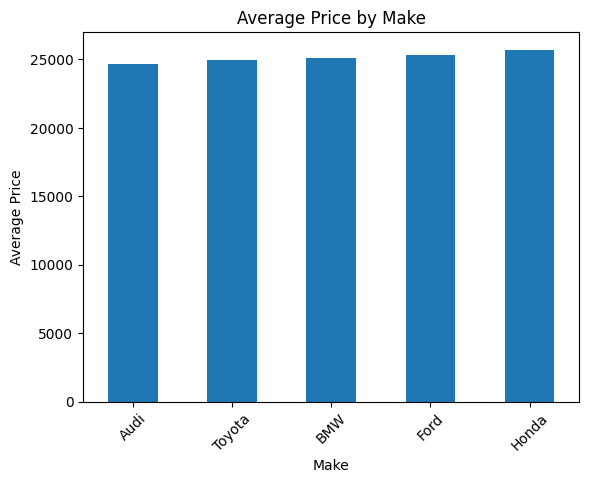

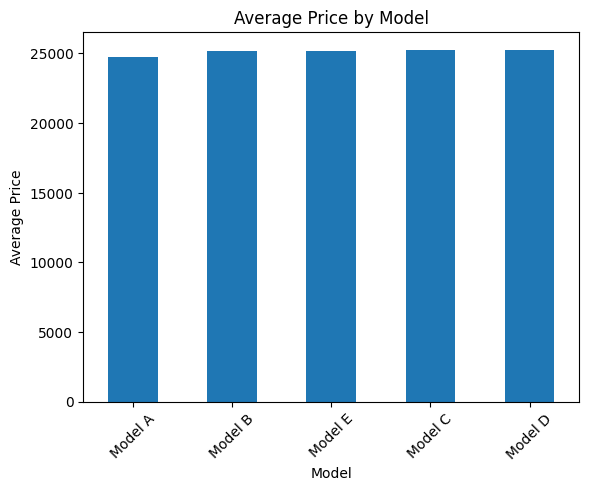

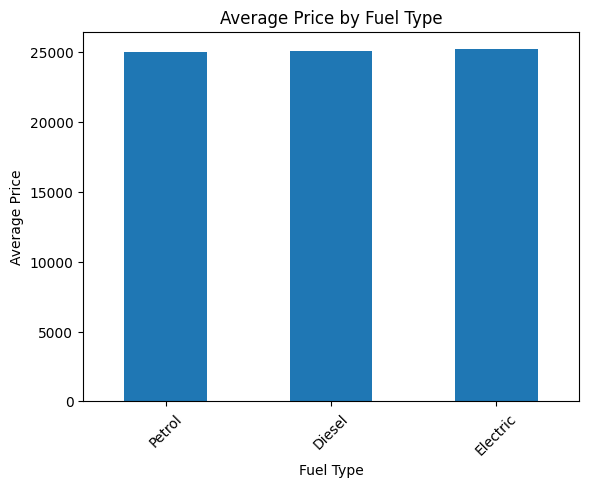

In [80]:
categorical_columns = ["Make", "Model", "Fuel Type"]

for column in categorical_columns:
    df.groupby(column)["Price"].mean().sort_values().plot(kind="bar")

    plt.title(f"Average Price by {column}")
    plt.xlabel(column)
    plt.ylabel("Average Price")
    plt.xticks(rotation=45)
    plt.show()

In [81]:
X=df.drop("Price",axis=1)
y=df["Price"]

In [82]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [83]:
categorical_columns = [
    "Make",
    "Model",
    "Fuel Type",
    "Transmission"
]

numerical_columns = [
    "Year",
    "Engine Size",
    "Mileage"
]

In [84]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder


In [85]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ("scaler", StandardScaler(), numerical_columns),
    ("encoding", OneHotEncoder(),categorical_columns )
])

In [86]:
X_train_preprocessor=preprocessor.fit_transform(X_train)
print("Original X_train Shape: ",X_train.shape)
print("Processed X_train shape: ",X_train_preprocessor.shape)

Original X_train Shape:  (800, 7)
Processed X_train shape:  (800, 18)


In [87]:
X_test_processed = preprocessor.transform(X_test)

print("Original X_test shape:", X_test.shape)
print("Processed X_test shape:", X_test_processed.shape)

Original X_test shape: (200, 7)
Processed X_test shape: (200, 18)


In [88]:
print(X_train_preprocessor[:5])

[[-1.58202424  0.08905172 -1.37861634  0.          0.          0.
   1.          0.          0.          1.          0.          0.
   0.          0.          1.          0.          1.          0.        ]
 [-0.61737531 -0.6853111   1.54990904  1.          0.          0.
   0.          0.          0.          0.          0.          0.
   1.          0.          1.          0.          1.          0.        ]
 [ 0.18649879  0.08905172  1.24072716  1.          0.          0.
   0.          0.          0.          0.          1.          0.
   0.          0.          1.          0.          1.          0.        ]
 [-1.09969978 -1.55646927 -0.82956938  0.          1.          0.
   0.          0.          0.          0.          0.          1.
   0.          1.          0.          0.          1.          0.        ]
 [ 1.47269736  0.9602099   0.94125771  0.          0.          1.
   0.          0.          0.          0.          0.          0.
   1.          0.          1.          0

In [89]:
from sklearn.ensemble import GradientBoostingRegressor

gb_pipeline=Pipeline([
    ("preprocessor",preprocessor),
    ("model",GradientBoostingRegressor())
])

In [90]:
gb_pipeline.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('scaler', ...), ('encoding', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transfo

In [91]:
y_pred_gr=gb_pipeline.predict(X_test)

In [92]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, y_pred_gr)
mse = mean_squared_error(y_test, y_pred_gr)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_gr)

In [93]:
print("MAE: ",mae)
print("MSE: ",mse)
print("RMSE: ",rmse)
print("R2: ",r2)

MAE:  1858.0393672948715
MSE:  5288596.153095677
RMSE:  2299.6947956404297
R2:  0.8067505754972744


In [94]:
from sklearn.linear_model import LinearRegression

lr_pipeline=Pipeline([
    ("preprocessor",preprocessor),
    ("model",LinearRegression())
])

lr_pipeline.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('scaler', ...), ('encoding', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transfo

In [95]:
lr_pred=lr_pipeline.predict(X_test)

mae = mean_absolute_error(y_test, lr_pred)
mse = mean_squared_error(y_test, lr_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, lr_pred)

In [96]:
print("MAE: ",mae)
print("MSE: ",mse)
print("RMSE: ",rmse)
print("R2: ",r2)

MAE:  1810.5547575776332
MSE:  5005471.209262067
RMSE:  2237.2910425919263
R2:  0.8170961815663226


In [97]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

scores=cross_val_score(
    lr_pipeline,
    X_train,y_train,cv=5,scoring="r2"
)


In [98]:
print("CV Scores:", scores)
print("Mean CV R²:", scores.mean())

CV Scores: [0.82813075 0.8661533  0.83152382 0.8345089  0.83658628]
Mean CV R²: 0.8393806097417544


In [99]:
param_grid = {
    "model__n_estimators": [50, 100],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [2, 3]
}

In [101]:
grid=GridSearchCV(
    estimator=gb_pipeline,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    scoring="r2"
)
grid.fit(X_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...Regressor())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__learning_rate': [0.05, 0.1], 'model__max_depth': [2, 3], 'model__n_estimators': [50, 100]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;

In [102]:
print("Best Parameters:", grid.best_params_)
print("Best CV R²:", grid.best_score_)

Best Parameters: {'model__learning_rate': 0.1, 'model__max_depth': 2, 'model__n_estimators': 100}
Best CV R²: 0.8122590046634055


In [103]:
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

In [104]:

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

In [105]:
print("MAE: ",mae)
print("MSE: ",mse)
print("RMSE: ",rmse)
print("R2: ",r2)

MAE:  1860.9183339977692
MSE:  5342577.870267546
RMSE:  2311.401711141433
R2:  0.8047780414872752


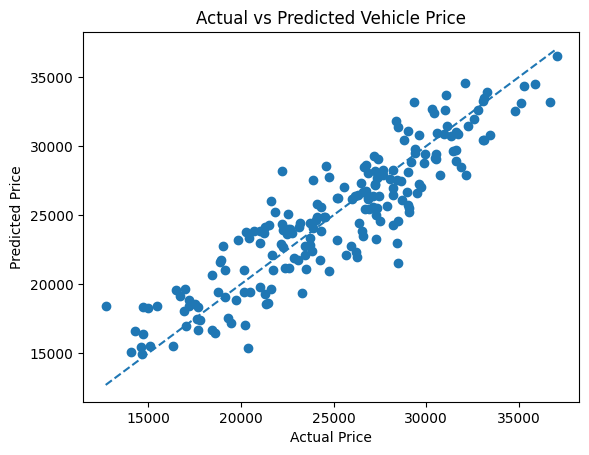

In [106]:
y_pred_lr=lr_pipeline.predict(X_test)

plt.Figure(figsize=(8,6))

plt.scatter(y_test,y_pred_lr)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Vehicle Price")
plt.plot(
    [y_test.min(),y_test.max()],
    [y_test.min(),y_test.max()],
    linestyle="--"
)

plt.savefig("images/actual_vs_predicted_price.png")